In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


In [2]:
!pip install wandb

## imports

In [3]:
import wandb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset,DataLoader
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.feature_extraction.text import TfidfVectorizer
import torch
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter
from datasets import load_dataset
from transformers import AutoTokenizer,AutoModel,pipeline,T5ForConditionalGeneration, T5Tokenizer
import torch.nn as nn
from sentence_transformers import SentenceTransformer, util

In [4]:
# wandb.login()

In [5]:
from kaggle_secrets import UserSecretsClient
import wandb
user_secrets = UserSecretsClient()
api_key = user_secrets.get_secret("WANDB_API_KEY")
wandb.login(key=api_key)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


True

## wandb initilization and stuffs...

In [6]:
run = wandb.init(
    entity="dlgenai-t22026",
    project="dlgenai-t226",
    name="model1-dl-genai",
    config={"model": "TF-IDF + Cosine Similarity",
    "dataset": "Smart MCQ Solver",
    "task": "MCQ Answer Ranking",
    "metric": "MAP@3"
    }
)

wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260713_150605-iobwbzwy
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run model1-dl-genai
wandb: ⭐️ View project at https://wandb.ai/dlgenai-t22026/dlgenai-t226
wandb: 🚀 View run at https://wandb.ai/dlgenai-t22026/dlgenai-t226/runs/iobwbzwy


## loading data

In [7]:
sample=pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv")

In [8]:
train_df=pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test_df=pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")

## EDA

In [9]:
train_df.head()

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


In [10]:
train_df.shape

(2000, 8)

### **the training data has 2000 rows and 8 columns**

In [11]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB


In [12]:
train_df.describe()

,id
count,2000.000000
mean,1000.500000
std,577.494589
min,1.000000
25%,500.750000
50%,1000.500000
75%,1500.250000
max,2000.000000


### most of them are text so cant get much insight from descriptive stats

In [13]:
train_df.isnull().sum()

id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

### **No missing values**

In [14]:
train_df["answer"].value_counts()

answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64

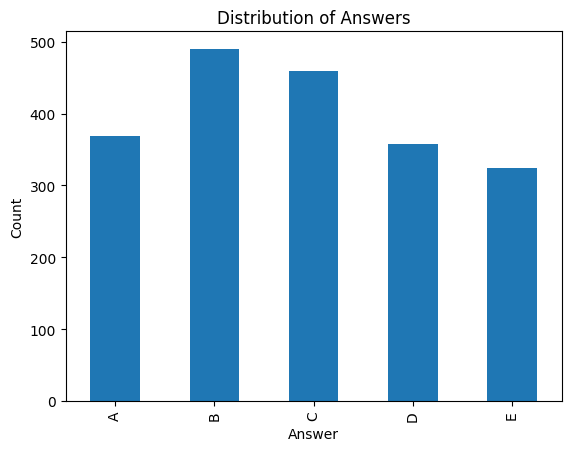

In [15]:
train_df["answer"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Answers")
plt.xlabel("Answer")
plt.ylabel("Count")
plt.show()

### **it has a little imbalance not much**

# DATA PREPROCESSING

## Data Split

In [16]:
train_data, val_data = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df["answer"])

### **we use stratify to keep the same answer distribution in both the training and validation datasets...for more reliable evaluation**

In [17]:
print(f"Training Samples   : {len(train_data)}")
print(f"Validation Samples : {len(val_data)}")

Training Samples   : 1600
Validation Samples : 400


# FEATURE ENGINEERING

In [18]:
def create_samples(df):
    texts = []
    labels = []
    options = ["A", "B", "C", "D", "E"]
    for _, row in df.iterrows():
        prompt = row["prompt"]
        for option in options:
            text = prompt + " " + str(row[option])
            texts.append(text)
            if option == row["answer"]:
                labels.append(1)
            else:
                labels.append(0)
    return texts, labels

In [19]:
train_texts, train_labels = create_samples(train_data)
val_texts, val_labels = create_samples(val_data)
print("Training Samples :", len(train_texts))
print("Validation Samples:", len(val_texts))

Training Samples : 8000
Validation Samples: 2000


## Convert Text into TF-IDF Features

In [20]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words="english",
    ngram_range=(1, 2)
)

In [21]:
X_train = vectorizer.fit_transform(train_texts)
X_val = vectorizer.transform(val_texts)

### **converted the text into numerical feature vectors**

### **pytorch works with tensors so we have to convert it first**

## PyTorch Data Pipeline

In [22]:
X_train_tensor = torch.tensor(X_train.toarray(), dtype=torch.float32)
X_val_tensor = torch.tensor(X_val.toarray(), dtype=torch.float32)

In [23]:
y_train_tensor = torch.tensor(train_labels, dtype=torch.float32)
y_val_tensor = torch.tensor(val_labels, dtype=torch.float32)

### **we have converted them to tensors ....these tensors will be used to train the neural network**

## TensorDataset

In [24]:
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

In [25]:
val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

In [26]:
BATCH_SIZE = 64
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

In [27]:
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [28]:
print("Training Batches :", len(train_loader))
print("Validation Batches:", len(val_loader))

Training Batches : 125
Validation Batches: 32


## Build the Neural Network

In [29]:
input_size = X_train_tensor.shape[1]
print("Input Size:", input_size)

Input Size: 10000


In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

Using Device: cuda


In [31]:
input_size = X_train_tensor.shape[1]

In [32]:
class MCQClassifier(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 768),
            nn.ReLU(),
            nn.Dropout(0.35),
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1)
        )
    def forward(self, x):
        return self.network(x)

In [33]:
model = MCQClassifier(input_size).to(device)
print(model)

MCQClassifier(
  (network): Sequential(
    (0): Linear(in_features=10000, out_features=768, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.35, inplace=False)
    (3): Linear(in_features=768, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=1, bias=True)
  )
)


In [34]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

# Model training

In [35]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).unsqueeze(1)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    return running_loss / len(loader)

## validate

In [36]:
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).unsqueeze(1)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            running_loss += loss.item()
    return running_loss / len(loader)

## training loop

In [37]:
best_val_loss = float("inf")
EPOCHS = 20
for epoch in range(EPOCHS):
    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )
    val_loss = validate(
        model,
        val_loader,
        criterion,
        device
    )
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pth")
        print(f"✅ Best model saved! Validation Loss: {val_loss:.4f}")
    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Validation Loss: {val_loss:.4f}"
    )
    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "validation_loss": val_loss
    })

✅ Best model saved! Validation Loss: 0.3154
Epoch [1/20] | Train Loss: 0.4545 | Validation Loss: 0.3154
✅ Best model saved! Validation Loss: 0.1327
Epoch [2/20] | Train Loss: 0.2039 | Validation Loss: 0.1327
✅ Best model saved! Validation Loss: 0.0906
Epoch [3/20] | Train Loss: 0.1088 | Validation Loss: 0.0906
✅ Best model saved! Validation Loss: 0.0796
Epoch [4/20] | Train Loss: 0.0797 | Validation Loss: 0.0796
✅ Best model saved! Validation Loss: 0.0619
Epoch [5/20] | Train Loss: 0.0617 | Validation Loss: 0.0619
✅ Best model saved! Validation Loss: 0.0571
Epoch [6/20] | Train Loss: 0.0500 | Validation Loss: 0.0571
Epoch [7/20] | Train Loss: 0.0487 | Validation Loss: 0.0583
Epoch [8/20] | Train Loss: 0.0438 | Validation Loss: 0.0610
✅ Best model saved! Validation Loss: 0.0508
Epoch [9/20] | Train Loss: 0.0409 | Validation Loss: 0.0508
✅ Best model saved! Validation Loss: 0.0487
Epoch [10/20] | Train Loss: 0.0356 | Validation Loss: 0.0487
✅ Best model saved! Validation Loss: 0.0475
Epo

## Model Evaluation

In [38]:
model.eval()
predictions = []
with torch.no_grad():
    for X_batch, _ in val_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        scores = torch.sigmoid(outputs)
        predictions.extend(scores.squeeze().cpu().numpy())

In [39]:
option_names = ["A", "B", "C", "D", "E"]
predicted_answers = []
for i in range(0, len(predictions), 5):
    scores = predictions[i:i+5]
    ranked = sorted(
        zip(option_names, scores),
        key=lambda x: x[1],
        reverse=True
    )
    top3 = [option for option, _ in ranked[:3]]
    predicted_answers.append(top3)

In [40]:
true_answers = val_data["answer"].tolist()

In [41]:
def apk(actual, predicted, k=3):
    if actual in predicted[:k]:
        return 1 / (predicted.index(actual) + 1)
    return 0
def mapk(actuals, predictions, k=3):
    scores = []
    for actual, predicted in zip(actuals, predictions):
        scores.append(apk(actual, predicted, k))
    return sum(scores) / len(scores)

In [42]:
map3_score = mapk(
    true_answers,
    predicted_answers
)
print(f"Validation MAP@3: {map3_score:.4f}")
wandb.log({
    "MAP@3": map3_score
})

Validation MAP@3: 0.9671


### i dont think 0.9671 is possible there must be some issue

In [43]:
for i in range(5):
    print(f"Question {i+1}")
    print("Actual:", true_answers[i])
    print("Predicted:", predicted_answers[i])
    print()

Question 1
Actual: C
Predicted: ['A', 'C', 'E']

Question 2
Actual: D
Predicted: ['D', 'C', 'A']

Question 3
Actual: E
Predicted: ['E', 'A', 'B']

Question 4
Actual: D
Predicted: ['D', 'E', 'B']

Question 5
Actual: D
Predicted: ['D', 'E', 'B']



In [44]:
correct_top1 = 0
for actual, pred in zip(true_answers, predicted_answers):
    if actual == pred[0]:
        correct_top1 += 1
print(correct_top1)
print(len(true_answers))
print(correct_top1 / len(true_answers))

379
400
0.9475


In [45]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()
print("Model saved successfully!")

Model saved successfully!


## Submit

In [46]:
test_texts = []
for _, row in test_df.iterrows():
    prompt = row["prompt"]
    for option in ["A", "B", "C", "D", "E"]:
        text = prompt + " " + str(row[option])
        test_texts.append(text)

In [47]:
X_test = vectorizer.transform(test_texts)

In [48]:
X_test_tensor = torch.tensor(
    X_test.toarray(),
    dtype=torch.float32
)
test_dataset = TensorDataset(X_test_tensor)
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [49]:
model.eval()
test_scores = []
with torch.no_grad():
    for (X_batch,) in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        scores = torch.sigmoid(outputs)
        test_scores.extend(scores.squeeze().cpu().numpy())

In [50]:
option_names = ["A", "B", "C", "D", "E"]
predictions = []
for i in range(0, len(test_scores), 5):
    scores = test_scores[i:i+5]
    ranked = sorted(
        zip(option_names, scores),
        key=lambda x: x[1],
        reverse=True
    )
    top3 = " ".join([option for option, _ in ranked[:3]])
    predictions.append(top3)

In [51]:
submission = test_df[["id"]].copy()
submission["prediction"] = predictions
submission.head()

,id,prediction
0,1,A C D
1,2,B A C
2,3,B D E
3,4,E C A
4,5,C A D


In [52]:
submission.to_csv("submission_model1.csv", index=False)
print("Submission file saved successfully!")

Submission file saved successfully!


# MILESTONE 1

### Q1)

In [53]:
# train_df["answer"].value_counts()

### Q2)

In [54]:
# cleaned=train_df["prompt"].str.lower()

In [55]:
# import string

In [56]:
# for char in string.punctuation:
#     cleaned=cleaned.str.replace(char,"",regex=False)

In [57]:
# len(cleaned.str.split().explode().unique())

### Q3)

In [58]:
# words = cleaned.iloc[1].split()
# filtered = [word for word in words if word not in ENGLISH_STOP_WORDS]
# len(filtered)

### Q4)

In [59]:
# combined = train_df[["prompt", "A", "B", "C", "D", "E"]].apply(lambda row: " ".join(row), axis=1)

In [60]:
# vectorizer = TfidfVectorizer(stop_words="english")
# vectorizer.fit_transform(combined)

In [61]:
# len(vectorizer.vocabulary_)

### Q5)

In [62]:
# prompt_vec = vectorizer.transform([train_df.loc[1, "prompt"]])
# option_a_vec = vectorizer.transform([train_df.loc[1, "A"]])

In [63]:
# score = cosine_similarity(prompt_vec, option_a_vec)
# round(float(score[0][0]), 4)

### Q6)

In [64]:
# correct = 0
# for idx, row in train_df.iterrows():
#     prompt_vec = vectorizer.transform([row["prompt"]])
#     scores = {}
#     for option in ["A", "B", "C", "D", "E"]:
#         option_vec = vectorizer.transform([row[option]])
#         scores[option] = cosine_similarity(prompt_vec, option_vec)[0][0]
#     best_option = max(scores, key=lambda x: scores[x])
#     if best_option == row["answer"]:
#         correct += 1

In [65]:
# percentage = round((correct / len(train_df)) * 100, 2)
# print(percentage)

### Q7)

In [66]:
# top3 = train_df["answer"].value_counts().index[:3].tolist()

In [67]:
# def apk(actual, predicted, k=3):
#     if actual in predicted[:k]:
#         return 1 / (predicted.index(actual) + 1)
#     return 0

In [68]:
# scores = train_df["answer"].apply(lambda x: apk(x, top3))
# map3 = round(scores.mean(), 4)
# print(map3)

### Q8)

In [69]:
# map3_scores = []

In [70]:
# for idx, row in train_df.iterrows():
#     prompt_vec = vectorizer.transform([row["prompt"]])
#     sim_scores = {}
#     for option in ["A", "B", "C", "D", "E"]:
#         option_vec = vectorizer.transform([row[option]])
#         sim_scores[option] = cosine_similarity(prompt_vec, option_vec)[0][0]
#     top3_preds = sorted(sim_scores, key=lambda x: sim_scores[x], reverse=True)[:3]
#     map3_scores.append(apk(row["answer"], top3_preds))

In [71]:
# print(round(sum(map3_scores) / len(map3_scores), 4))

# MILESTONE 2

### Q1)

In [72]:
# dataset = load_dataset("csv", data_files="/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")["train"]
# def combine(row):
#     return {"combined_text": row["prompt"] + " " + row["A"]}
# dataset = dataset.map(combine)
# print(len(dataset[51]["combined_text"]))

### Q2)

In [73]:
# tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
# print(tokenizer.vocab_size)

### Q3)

In [74]:
# print(tokenizer.sep_token_id)

### Q4)

In [75]:
# prompts = list(dataset["prompt"])
# tokens = tokenizer(prompts, padding='max_length', truncation=True, max_length=128, return_tensors='pt')
# print(tokens["input_ids"].shape)

### Q5)

In [76]:
# model = AutoModel.from_pretrained("bert-base-uncased")
# prompt = dataset[0]["prompt"]
# tokens = tokenizer(prompt, return_tensors='pt')
# output = model(**tokens)
# print(output.last_hidden_state.shape)

### Q6)

In [77]:
# cls_embedding = output.last_hidden_state[0, 0, :]
# print(round(cls_embedding[:5].sum().item(), 4))

### Q7)

In [78]:
# model = AutoModel.from_pretrained("bert-base-uncased", output_attentions=True)
# text = "Light-ion fusion is a technique."
# tokens = tokenizer(text, return_tensors='pt')
# print(tokenizer.convert_ids_to_tokens(tokens['input_ids'][0]))
# output = model(**tokens)
# attentions = output.attentions[-1][0][0]
# token_list = tokenizer.convert_ids_to_tokens(tokens['input_ids'][0])
# fusion_idx = token_list.index('fusion')
# print(round(attentions[0][fusion_idx].item(), 4))

### Q8)

In [79]:
# model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
# prompt = dataset[0]["prompt"]
# option_b = dataset[0]["B"]
# emb1 = model.encode(prompt)
# emb2 = model.encode(option_b)
# score = util.cos_sim(emb1, emb2)
# print(round(float(score), 4))

### Q9)

In [80]:
# st_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

# options = ["A", "B", "C", "D", "E"]
# prompt_embs = st_model.encode(list(train_df["prompt"]), show_progress_bar=True)
# option_embs = {opt: st_model.encode(list(train_df[opt]), show_progress_bar=True) for opt in options}

# minilm_preds = []
# for i in range(len(train_df)):
#     scores = {}
#     for opt in options:
#         scores[opt] = float(util.cos_sim(prompt_embs[i], option_embs[opt][i]))
#     top3 = sorted(scores, key=lambda x: scores[x], reverse=True)[:3]
#     minilm_preds.append(top3)

# minilm_map3 = np.mean([apk(train_df.iloc[i]["answer"], minilm_preds[i]) for i in range(len(train_df))])
# print("MiniLM MAP@3:", round(minilm_map3, 4))

# train_df["combined"] = train_df[["prompt","A","B","C","D","E"]].apply(lambda row: " ".join(row), axis=1)
# vec = TfidfVectorizer(stop_words="english")
# tfidf_preds = []
# for i in range(len(train_df)):
#     prompt_vec = vec.fit_transform([train_df.iloc[i]["prompt"]])
#     sim_scores = {}
#     for opt in options:
#         opt_vec = vec.transform([train_df.iloc[i][opt]])
#         sim_scores[opt] = cosine_similarity(prompt_vec, opt_vec)[0][0]
#     top3 = sorted(sim_scores, key=lambda x: sim_scores[x], reverse=True)[:3]
#     tfidf_preds.append(top3)
# count = 0
# for i in range(len(train_df)):
#     answer = train_df.iloc[i]["answer"]
#     if answer not in tfidf_preds[i] and answer in minilm_preds[i]:
#         count += 1
# print("MiniLM wins over TF-IDF count:", count)

### Q10)

In [81]:
# classifier = pipeline("zero-shot-classification")
# prompt = dataset[1]["prompt"]
# candidate_labels = [dataset[1]["A"], dataset[1]["B"], dataset[1]["C"]]
# result = classifier(prompt, candidate_labels)
# print(round(result["scores"][0], 4))

### Q11)

In [82]:
# result_single = classifier(prompt, candidate_labels)
# result_multi = classifier(prompt, candidate_labels, multi_label=True)
# sum_single = sum(result_single["scores"])
# sum_multi = sum(result_multi["scores"])
# print(round(abs(sum_single - sum_multi), 4))

### Q12)

In [83]:
# tokenizer_flan = T5Tokenizer.from_pretrained("google/flan-t5-small")
# model_flan = T5ForConditionalGeneration.from_pretrained("google/flan-t5-small")
# prompt_text = dataset[0]["prompt"]
# option_a = dataset[0]["A"]
# option_b = dataset[0]["B"]
# input_text = f"Question: {prompt_text}. Is the correct answer A: {option_a} or B: {option_b}? Answer with just the letter A or B."
# inputs = tokenizer_flan(input_text, return_tensors="pt")
# outputs = model_flan.generate(**inputs, max_new_tokens=5)
# print(tokenizer_flan.decode(outputs[0], skip_special_tokens=True))

# MILESTONE 3

### Q1)

In [84]:
# !pip install -q faiss-cpu

# import pandas as pd
# import numpy as np
# import faiss
# from sentence_transformers import SentenceTransformer, CrossEncoder
# from transformers import AutoTokenizer, pipeline
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.metrics.pairwise import cosine_similarity

# print("Creating knowledge base")
# kb = []
# for idx, row in train_df.iterrows():
#     correct_letter = row["answer"]
#     kb.append(str(row[correct_letter]))

# print("Loading embedding model and creating index")
# model = SentenceTransformer("all-MiniLM-L6-v2")
# kb_embeddings = model.encode(kb, show_progress_bar=False)

# index = faiss.IndexFlatL2(kb_embeddings.shape[1])
# index.add(kb_embeddings)

# print("Knowledge base successfully created")

# # Zero-shot classifier for Q1, Q2, Q6
# zs = pipeline(
#     "zero-shot-classification",
#     model="facebook/bart-large-mnli"
# )

# row_150 = train_df.iloc[150]
# prompt_150 = str(row_150["prompt"])
# labels_150 = [
#     str(row_150["A"]),
#     str(row_150["B"]),
#     str(row_150["C"]),
#     str(row_150["D"]),
#     str(row_150["E"])
# ]
# ans_150 = str(row_150[row_150["answer"]])

In [85]:
# result = zs(prompt_150, candidate_labels=labels_150)
# print(result)

In [86]:
# ground_truth_score = result["scores"][result["labels"].index(ans_150)]
# print(round(ground_truth_score, 3))

### Q2)

In [87]:
# query_embedding = model.encode([prompt_150], show_progress_bar=False)
# D, I = index.search(query_embedding, k=10)
# print("Retrieved KB indices:")
# print(I[0])
# print("\nRetrieved documents:")
# for rank, idx in enumerate(I[0], start=1):
#     print(f"Rank {rank}: KB index {idx}")
#     print(kb[idx][:120], "...\n")
# if 150 in I[0]:
#     rank = list(I[0]).index(150) + 1
#     print(f"True document found at Rank {rank}")
# else:
#     print("True document is NOT in the top 10.")

### Q3)

In [88]:
# cross_encoder = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')
# retrieved_indices = I[0]
# docs_10 = [kb[i] for i in retrieved_indices]
# pairs = [[prompt_150, doc] for doc in docs_10]
# ce_scores = cross_encoder.predict(pairs)

In [89]:
# ranking = sorted(
#     zip(retrieved_indices, ce_scores),
#     key=lambda x: x[1],
#     reverse=True
# )
# for rank, (idx, score) in enumerate(ranking, start=1):
#     print(f"Rank {rank}: KB index {idx}, Score: {score:.4f}")
# for rank, (idx, score) in enumerate(ranking, start=1):
#     if idx == 150:
#         print(f"\nTrue document found at Rank {rank}")
#         break

### Q4)

In [90]:
# row_42 = train_df.iloc[42]
# prompt_42 = str(row_42["prompt"])
# query_embedding = model.encode([prompt_42], show_progress_bar=False)
# D, I = index.search(query_embedding, k=5)
# docs_5 = [kb[i] for i in I[0]]
# concatenated_docs = " ".join(docs_5)
# text = f"Context: {concatenated_docs} Question: {prompt_42}"
# tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
# tokens = tokenizer(text, truncation=False)
# print("Total tokens:", len(tokens["input_ids"]))

### Q5)

In [91]:
# row_150 = train_df.iloc[150]
# prompt_150 = str(row_150["prompt"])
# true_document = kb[150]
# rag_prompt = f"Context: {true_document} Question: {prompt_150}"
# result_rag = zs(
#     rag_prompt,
#     candidate_labels=labels_150
# )
# print(result_rag)
# ground_truth_score = result_rag["scores"][result_rag["labels"].index(ans_150)]
# print("Ground-truth score:", round(ground_truth_score, 3))

### Q6)

In [92]:
# row_150 = train_df.iloc[150]
# prompt_150 = str(row_150["prompt"])
# wrong_document = kb[999]
# adversarial_prompt = f"Context: {wrong_document} Question: {prompt_150}"
# result_adv = zs(
#     adversarial_prompt,
#     candidate_labels=labels_150
# )
# print(result_adv)
# ground_truth_score = result_adv["scores"][result_adv["labels"].index(ans_150)]
# print("Ground-truth score:", round(ground_truth_score, 3))

### Q7)

In [93]:
# hits = 0
# for i in range(100):
#     prompt = str(train_df.iloc[i]["prompt"])
#     correct_option = train_df.iloc[i][train_df.iloc[i]["answer"]]
#     query_embedding = model.encode([prompt], show_progress_bar=False)
#     D, I = index.search(query_embedding, k=5)
#     retrieved_docs = [kb[idx] for idx in I[0]]
#     if any(correct_option == doc for doc in retrieved_docs):
#         hits += 1
# hit_rate = (hits / 100) * 100
# print("Hits:", hits)
# print("Hit Rate:", round(hit_rate, 1))

### Q8)

In [94]:
# def apk(actual, predicted, k=3):
#     if actual in predicted[:k]:
#         return 1 / (predicted.index(actual) + 1)
#     return 0
# scores = []
# for i in range(20):
#     row = train_df.iloc[i]
#     prompt = str(row["prompt"])
#     query_embedding = model.encode([prompt], show_progress_bar=False)
#     D, I = index.search(query_embedding, k=5)
#     retrieved_indices = I[0]
#     docs = [kb[idx] for idx in retrieved_indices]
#     pairs = [[prompt, doc] for doc in docs]
#     ce_scores = cross_encoder.predict(pairs)
#     best_doc = docs[np.argmax(ce_scores)]
#     rag_prompt = f"Context: {best_doc} Question: {prompt}"
#     labels = [
#         str(row["A"]),
#         str(row["B"]),
#         str(row["C"]),
#         str(row["D"]),
#         str(row["E"])
#     ]
#     result = zs(rag_prompt, candidate_labels=labels)
#     option_map = {
#         row["A"]: "A",
#         row["B"]: "B",
#         row["C"]: "C",
#         row["D"]: "D",
#         row["E"]: "E"
#     }
#     predicted_letters = [option_map[label] for label in result["labels"]]
#     scores.append(apk(row["answer"], predicted_letters))
# final_map3 = np.mean(scores)
# print("MAP@3:", round(final_map3, 3))

# MODEL 1